# Group Assignment #4

## Spatial Autocorrelation of San Francisco: Vehicle Ownership 

**Author:** Abigail Adams and Jasmine Law

**Group:** Abigail Adams, Jasmine Law, Caleb Huang and Ronald Tien Giang

In [1]:
# to read and wrangle data
import pandas as pd

# to import data from LA Data portal
from sodapy import Socrata

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# For spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px

my plan is to use my ACS 2023 survey data from [Social explorer](https://www.socialexplorer.com/reports/socialexplorer/en/report/8b5702e4-f8ab-11ef-b1c5-774960b3ff30) and join it to the census block groups data from Census reporter. I will be joining on the FIPS column after cleaning both datasets. 


In [2]:
# read in block group geodataframe
bg = gpd.read_file('data/acs2023_blockgroups.geojson')

# check it
bg.shape

(682, 5)

In [3]:
# read in acs df
#sf_tracts = pd.read_csv('wk8_acs2023_sfdata.csv')

# check it
#sf_tracts.head(5)

Next, I will do some data cleaning on this dataset to make it more user friendly. I need to rename columns to something more intutitve and trim uncessary columns. 

In [4]:
# trim the data to the bare minimum columns
bg = bg[['geoid','B01003001','geometry']]

# rename the columns
bg.columns = ['FIPS','TotalPop','geometry'] 

# check it 
bg.head(2) # also check if the first row contains the population for the total city

,FIPS,TotalPop,geometry
0,05000US06075,836321.0,"MULTIPOLYGON (((-122.40536 37.70826, -122.4054..."
1,15000US060750101011,957.0,"MULTIPOLYGON (((-122.42108 37.81289, -122.4201..."


In [5]:
# delete first row which is for the entire city of SF
bg.drop(bg.head(1).index,inplace=True)

In [6]:
# fix FIPS code
bg['FIPS'] = bg['FIPS'].str.replace('15000US','') # what string are we replacing and with that. replace 15000US with nothing
bg.tail()

,FIPS,TotalPop,geometry
677,060759805011,155.0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
678,060759806001,1290.0,"MULTIPOLYGON (((-122.38694 37.72424, -122.3869..."
679,060759809001,322.0,"MULTIPOLYGON (((-122.40711 37.73906, -122.4070..."
680,060759901000,0.0,"MULTIPOLYGON (((-122.61228 37.81522, -122.5845..."
681,060759902000,0.0,"MULTIPOLYGON (((-122.45398 37.83903, -122.4454..."


Now I will be getting rid of census tracks with less than 100 people. 

In [7]:
# sort by total pop
bg.sort_values(by='TotalPop').head(20) # top 20 census block groups 

# there are only 6

,FIPS,TotalPop,geometry
676,060759804011,0.0,"MULTIPOLYGON (((-123.17382 37.77573, -123.1737..."
681,060759902000,0.0,"MULTIPOLYGON (((-122.45398 37.83903, -122.4454..."
680,060759901000,0.0,"MULTIPOLYGON (((-122.61228 37.81522, -122.5845..."
242,060750179032,0.0,"MULTIPOLYGON (((-122.42646 37.82881, -122.4241..."
670,060750615072,0.0,"MULTIPOLYGON (((-122.38789 37.7888, -122.38735..."
675,060759803001,49.0,"MULTIPOLYGON (((-122.51726 37.77068, -122.5167..."
677,060759805011,155.0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
674,060759802001,179.0,"MULTIPOLYGON (((-122.51064 37.78212, -122.5105..."
51,060750117003,184.0,"MULTIPOLYGON (((-122.4086 37.78923, -122.40775..."
76,060750123013,224.0,"MULTIPOLYGON (((-122.41152 37.78694, -122.4110..."


In [8]:
# delete less than 100 population geographies
bg = bg[bg['TotalPop']>100]

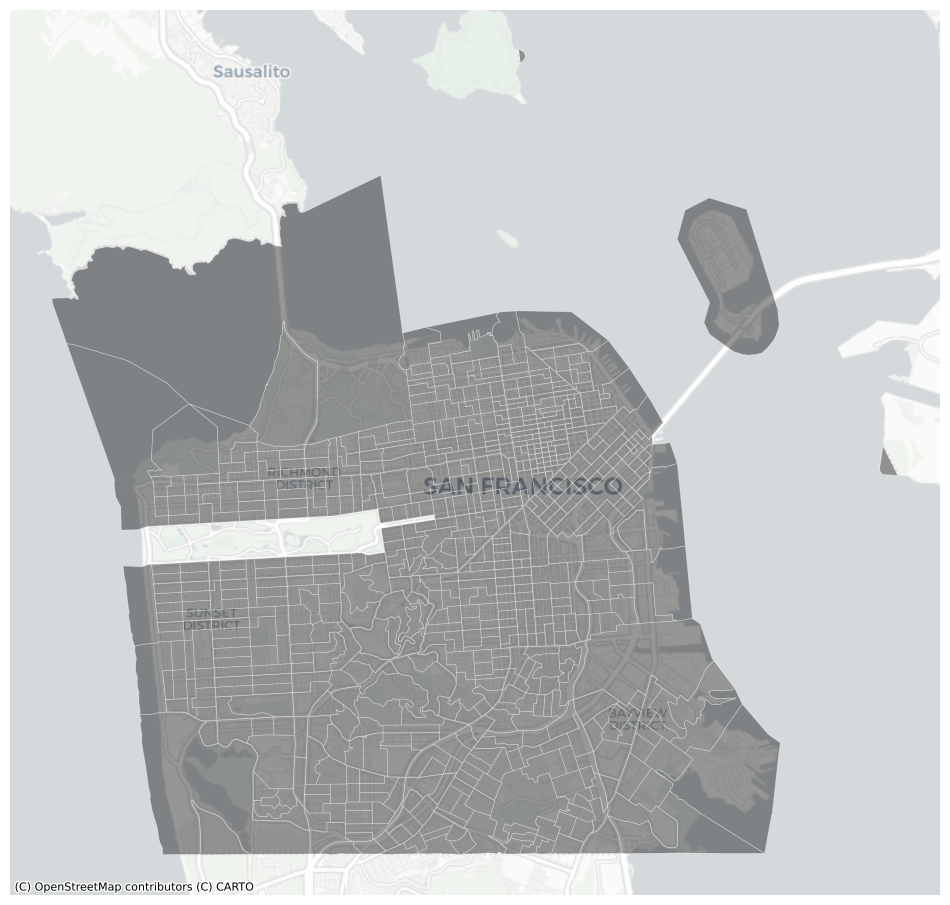

In [9]:
# get the layers into a web mercator projection
# reproject to web mercator
bg = bg.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12,12))

bg.plot(ax=ax,
         color='black', 
         edgecolor='white',
         lw=0.5,
         alpha=0.4)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

## Bring in census tract ACS data

Make sure that you include the census block groups with your dataset becasue that is necessary to join by the `FIPS` column. 

[ACS Data Source](https://www.socialexplorer.com/reports/socialexplorer/en/report/7e1c25fa-f973-11ef-9fa5-6b80bbd30f39)

In [10]:
# read in acs df
acs = pd.read_csv('data/acs2023_sf_blockgroups.csv')

# check it
acs.head(2)

,Geo_FIPS,Geo_QName,Geo_STUSAB,Geo_SUMLEV,Geo_GEOCOMP,Geo_US,Geo_REGION,Geo_DIVISION,Geo_STATE,Geo_COUNTY,...,Geo_BTBG,Geo_PLACESE,SE_A14006_001,SE_A10030_001,SE_A10030_002,SE_A10030_003,SE_A10030_004,SE_A10030_005,SE_A10030_006,SE_A10030_007
0,60750101011,"Block Group 1, Census Tract 101.01, San Franci...",ca,150,0,NaN,NaN,NaN,6,75,...,NaN,NaN,123826.0,541,185,276,80,0,0,0
1,60750101012,"Block Group 2, Census Tract 101.01, San Franci...",ca,150,0,NaN,NaN,NaN,6,75,...,NaN,NaN,66103.0,671,274,375,22,0,0,0


In [11]:
# check shape
acs.shape

(681, 54)

There are 681 rows (block groups) and 54 columns. 

## Data Cleaning: 

### Trimming Columns
When initially imported, the dataframe includes some columns that are not needed for my exploration, such as most of the 'GEO_' columns. The remaining columns are also named based on their codebook, but that is not intuitive to work with.  
Now, I am going to trim uncessary column, and rename the remaining columns based on its data dictionary. 

**Columns to remove:** 

* Geo_QName
* Geo_STUSAB
* Geo_SUMLEV
* Geo_GEOCOMP
* Geo_US
* Geo_REGION
* Geo_DIVISION
* Geo_STATE
* Geo_COUNTY
* Geo_BTBG
* Geo_PLACES

**Columns to keep:**   

* Geo_FIPS (census block group code)
* SE_A14006_001:     Median Household Income (In 2023 Inflation Adjusted Dollars)
* SE_A10030_001:     Occupied Housing Units
* SE_A10030_002:     Occupied Housing Units: No Vehicle Available
* SE_A10030_003:     Occupied Housing Units: 1 Vehicle Available
* SE_A10030_004:     Occupied Housing Units: 2 Vehicles Available
* SE_A10030_005:     Occupied Housing Units: 3 Vehicles Available
* SE_A10030_006:     Occupied Housing Units: 4 Vehicles Available
* SE_A10030_007:     Occupied Housing Units: 5 or More Vehicles Available

In [12]:
# keep selected columns 
acs = acs[['Geo_FIPS', 'SE_A14006_001', 'SE_A10030_001', 'SE_A10030_002', 'SE_A10030_003',
       'SE_A10030_004', 'SE_A10030_005', 'SE_A10030_006', 'SE_A10030_007']]

# check it 
acs.head(1)

,Geo_FIPS,SE_A14006_001,SE_A10030_001,SE_A10030_002,SE_A10030_003,SE_A10030_004,SE_A10030_005,SE_A10030_006,SE_A10030_007
0,60750101011,123826.0,541,185,276,80,0,0,0


In [13]:
# rename columns
acs.columns = ['FIPS', 'Median Household Income', 'Occupied Housing Units', 'No Vehicles', 'One Vehicle',
       'Two Vehicles', '3 Vehicles', '4 Vehicles', '5 + Vehicles']

# check it 
acs.tail()

,FIPS,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles
676,60759805011,13569.0,123,115,4,0,4,0,0
677,60759806001,142321.0,573,35,325,181,26,6,0
678,60759809001,53800.0,180,3,149,28,0,0,0
679,60759901000,NaN,0,0,0,0,0,0,0
680,60759902000,NaN,0,0,0,0,0,0,0


In [14]:
# sort by occupied units
acs.sort_values(by='Occupied Housing Units').head(10) # smallest 20 census block groups 

,FIPS,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles
680,60759902000,NaN,0,0,0,0,0,0,0
679,60759901000,NaN,0,0,0,0,0,0,0
241,60750179032,NaN,0,0,0,0,0,0,0
675,60759804011,NaN,0,0,0,0,0,0,0
669,60750615072,NaN,0,0,0,0,0,0,0
673,60759802001,NaN,0,0,0,0,0,0,0
674,60759803001,104333.0,40,24,12,4,0,0,0
676,60759805011,13569.0,123,115,4,0,4,0,0
50,60750117003,NaN,128,95,33,0,0,0,0
390,60750257021,85417.0,164,27,67,26,22,0,22


Zero occupied housing units means no one lives in these block groups by the survey's metric. That also means there is no values for the survey items. There are 6 Block groups with no occupied housing units. Therefore, I am going to remove these empty block groups from the dataframe. 

In [15]:
# delete rows with 0 occupied household units
acs = acs[acs['Occupied Housing Units']>0]

# check it
acs.sort_values(by='Occupied Housing Units').head(2) 

,FIPS,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles
674,60759803001,104333.0,40,24,12,4,0,0,0
676,60759805011,13569.0,123,115,4,0,4,0,0


## Merging

Now that the ACS data has been cleaned, I can merge it to the block group data frame from earlier that contains the geographic component. I will be doing a `left join` which joins the ACS onto the inital census block group data by their `FIPS` column. 

Before joining, I need to check that the data types of each `FIPS` column are the same to ensure they can join sucessfully. 

In [16]:
# check dims before joining 
bg.shape

(675, 3)

In [17]:
# check dims before joining 
acs.shape

(675, 9)

In [18]:
# check data type before merge
bg.info()
acs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 675 entries, 1 to 679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   FIPS      675 non-null    object  
 1   TotalPop  675 non-null    float64 
 2   geometry  675 non-null    geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 21.1+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 675 entries, 0 to 678
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FIPS                     675 non-null    int64  
 1   Median Household Income  615 non-null    float64
 2   Occupied Housing Units   675 non-null    int64  
 3   No Vehicles              675 non-null    int64  
 4   One Vehicle              675 non-null    int64  
 5   Two Vehicles             675 non-null    int64  
 6   3 Vehicles               675 non-null    int64  
 7   4 Vehicles               675 non-null

In [19]:
# change data type to int to match tract df (bg gdf)
bg["FIPS"] = bg["FIPS"].astype(int)

In [20]:
# merge
sf = bg.merge(acs,on="FIPS")

# verify
sf.head(5)

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles
0,60750101011,957.0,"MULTIPOLYGON (((-13627851.843 4553026.92, -136...",123826.0,541,185,276,80,0,0,0
1,60750101012,1047.0,"MULTIPOLYGON (((-13626835.941 4552031.596, -13...",66103.0,671,274,375,22,0,0,0
2,60750101021,1795.0,"MULTIPOLYGON (((-13627385.637 4551945.228, -13...",108417.0,907,303,446,148,10,0,0
3,60750102011,1310.0,"MULTIPOLYGON (((-13628270.293 4551530.447, -13...",189181.0,753,241,368,144,0,0,0
4,60750102012,1298.0,"MULTIPOLYGON (((-13628228.993 4551267.555, -13...",152328.0,622,211,246,70,95,0,0


In [21]:
# check new shape
sf.shape

(674, 11)

# spatial autocorrelation

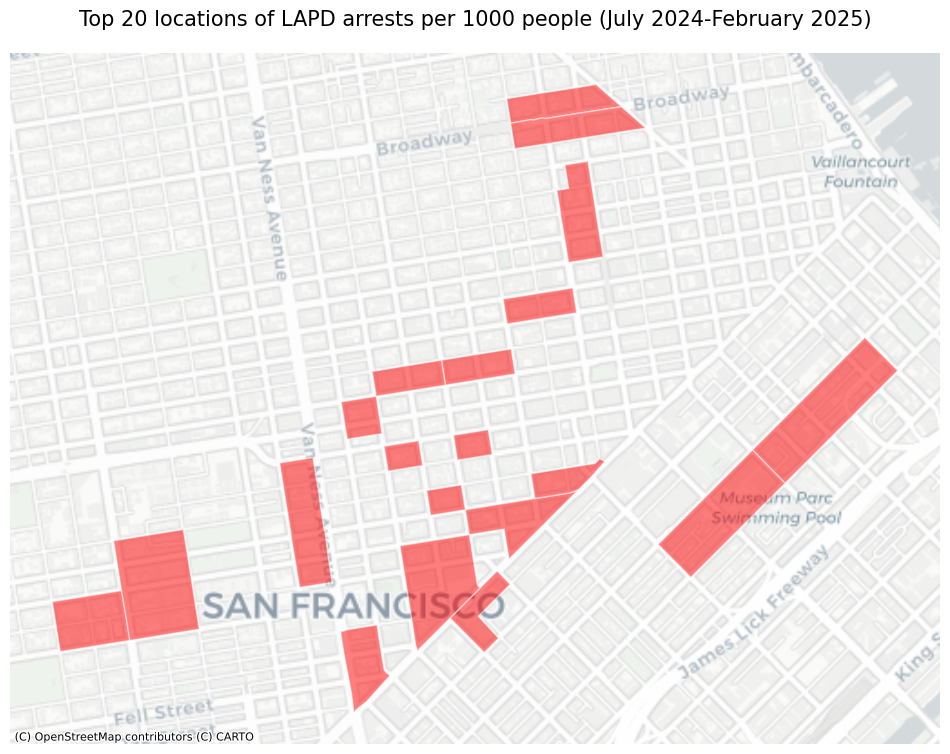

In [22]:
# map the top 20 geographies
fig,ax = plt.subplots(figsize=(12,10))
sf.sort_values(by='No Vehicles',ascending=False)[:20].plot(ax=ax,
                                                                 color='red',
                                                                 edgecolor='white',
                                                                 alpha=0.5)


# title
ax.set_title('Top 20 locations of LAPD arrests per 1000 people (July 2024-February 2025)',fontsize=15,pad=20)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

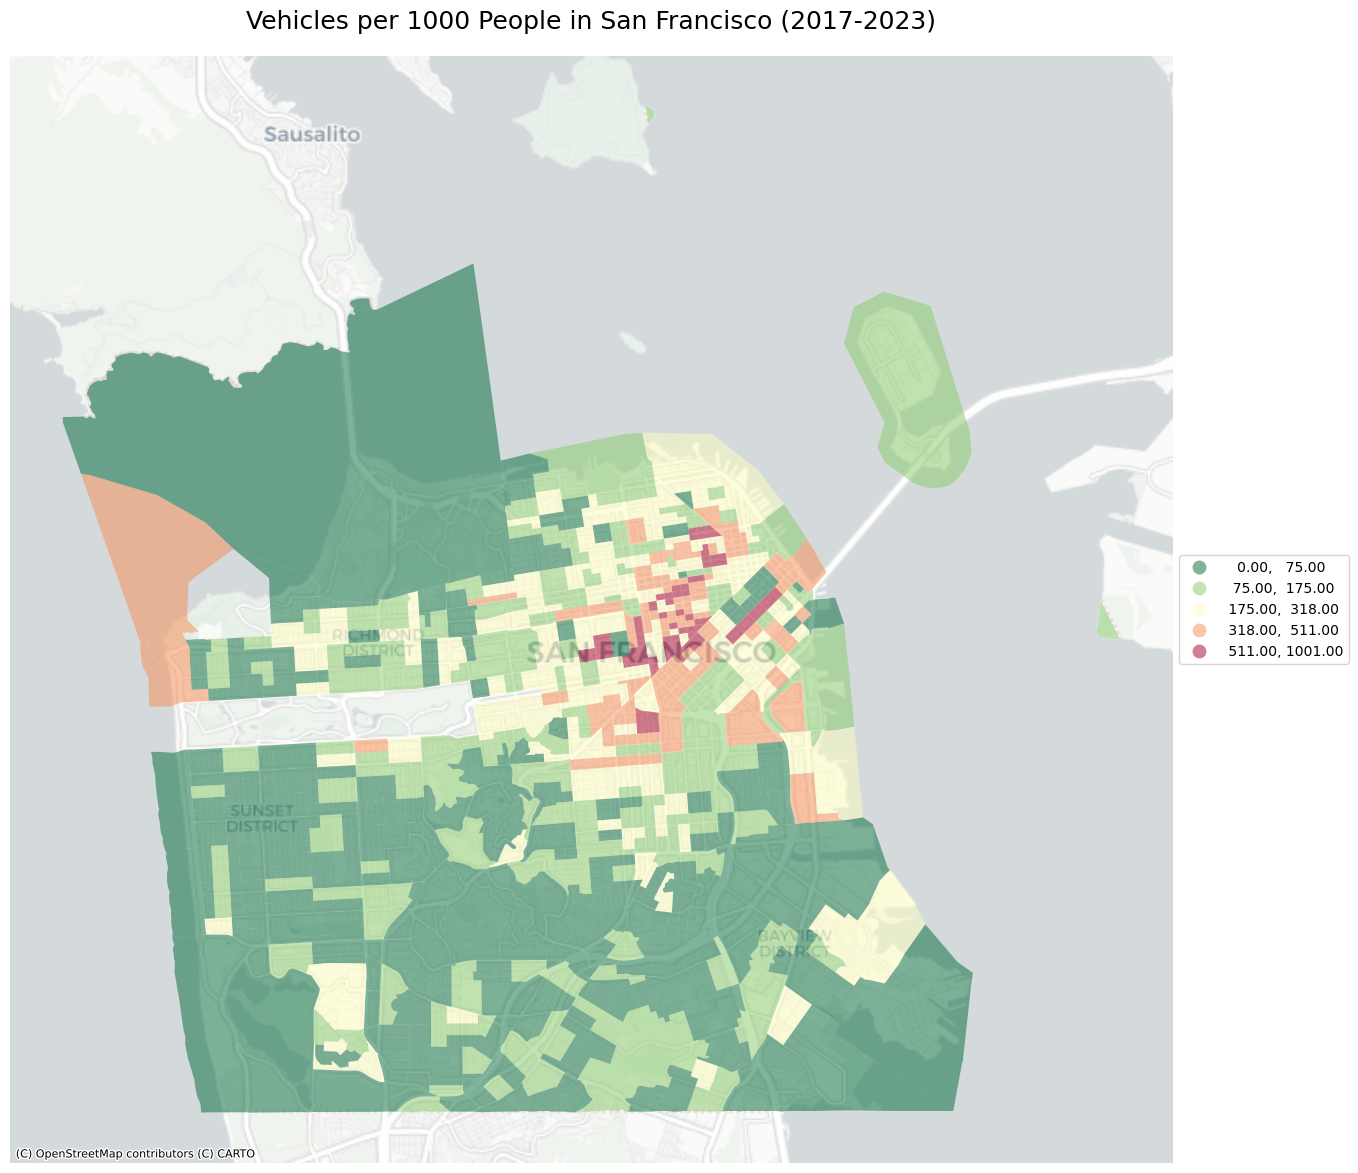

In [23]:
# create subplots to recieve cloropleth maps
fig,ax = plt.subplots(figsize=(15,15))

sf.plot(ax=ax,
        column='No Vehicles', # this defines the field to "choropleth"
        legend=True,
        alpha=0.5,
        cmap='RdYlGn_r', # the "_r" reverses the color
        scheme='naturalbreaks', # use quantiles when data is naturally distributied (not left or right skewed) check with histogram, use naturalbreaks when skewed
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})

ax.axis('off')
ax.set_title('Vehicles per 1000 People in San Francisco (2017-2023)',fontsize=18,pad=20)
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

markdown
-xplain why we need to normalize and add new variables 

In [24]:
# make column for total vehicles 
sf["total_vehicles"] = sf["One Vehicle"] + sf["Two Vehicles"] + sf["3 Vehicles"] + sf["4 Vehicles"] + sf["5 + Vehicles"] 

sf

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles,total_vehicles
0,60750101011,957.0,"MULTIPOLYGON (((-13627851.843 4553026.92, -136...",123826.0,541,185,276,80,0,0,0,356
1,60750101012,1047.0,"MULTIPOLYGON (((-13626835.941 4552031.596, -13...",66103.0,671,274,375,22,0,0,0,397
2,60750101021,1795.0,"MULTIPOLYGON (((-13627385.637 4551945.228, -13...",108417.0,907,303,446,148,10,0,0,604
3,60750102011,1310.0,"MULTIPOLYGON (((-13628270.293 4551530.447, -13...",189181.0,753,241,368,144,0,0,0,512
4,60750102012,1298.0,"MULTIPOLYGON (((-13628228.993 4551267.555, -13...",152328.0,622,211,246,70,95,0,0,411
...,...,...,...,...,...,...,...,...,...,...,...,...
669,60750615082,891.0,"MULTIPOLYGON (((-13624537.305 4549078.168, -13...",150063.0,539,471,68,0,0,0,0,68
670,60750615083,430.0,"MULTIPOLYGON (((-13624795.232 4548827.169, -13...",218224.0,277,49,129,96,3,0,0,228
671,60759805011,155.0,"MULTIPOLYGON (((-13628536.124 4539319.993, -13...",13569.0,123,115,4,0,4,0,0,8
672,60759806001,1290.0,"MULTIPOLYGON (((-13624051.395 4540543.786, -13...",142321.0,573,35,325,181,26,6,0,538


In [25]:
# Normalize vehicle access per 1,000 people, make new variable
sf["vehicles_per_1000"] = (sf["total_vehicles"] / sf["TotalPop"]) * 1000

sf

sf.sort_values(by="vehicles_per_1000").tail()

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles,total_vehicles,vehicles_per_1000
673,60759809001,322.0,"MULTIPOLYGON (((-13626297.6 4542629.041, -1362...",53800.0,180,3,149,28,0,0,0,177,549.689441
6,60750102022,891.0,"MULTIPOLYGON (((-13628342.984 4552057.662, -13...",219038.0,604,105,347,152,0,0,0,499,560.044893
262,60750204022,1124.0,"MULTIPOLYGON (((-13631036.248 4544144.227, -13...",121711.0,672,31,411,206,24,0,0,641,570.284698
128,60750132004,1103.0,"MULTIPOLYGON (((-13629231.425 4550567.808, -13...",154545.0,832,181,618,33,0,0,0,651,590.208522
653,60750615011,946.0,"MULTIPOLYGON (((-13625655.732 4549710.341, -13...",222455.0,686,53,510,59,64,0,0,633,669.133192


Now that I have normalized the amount of vehicles, I can 

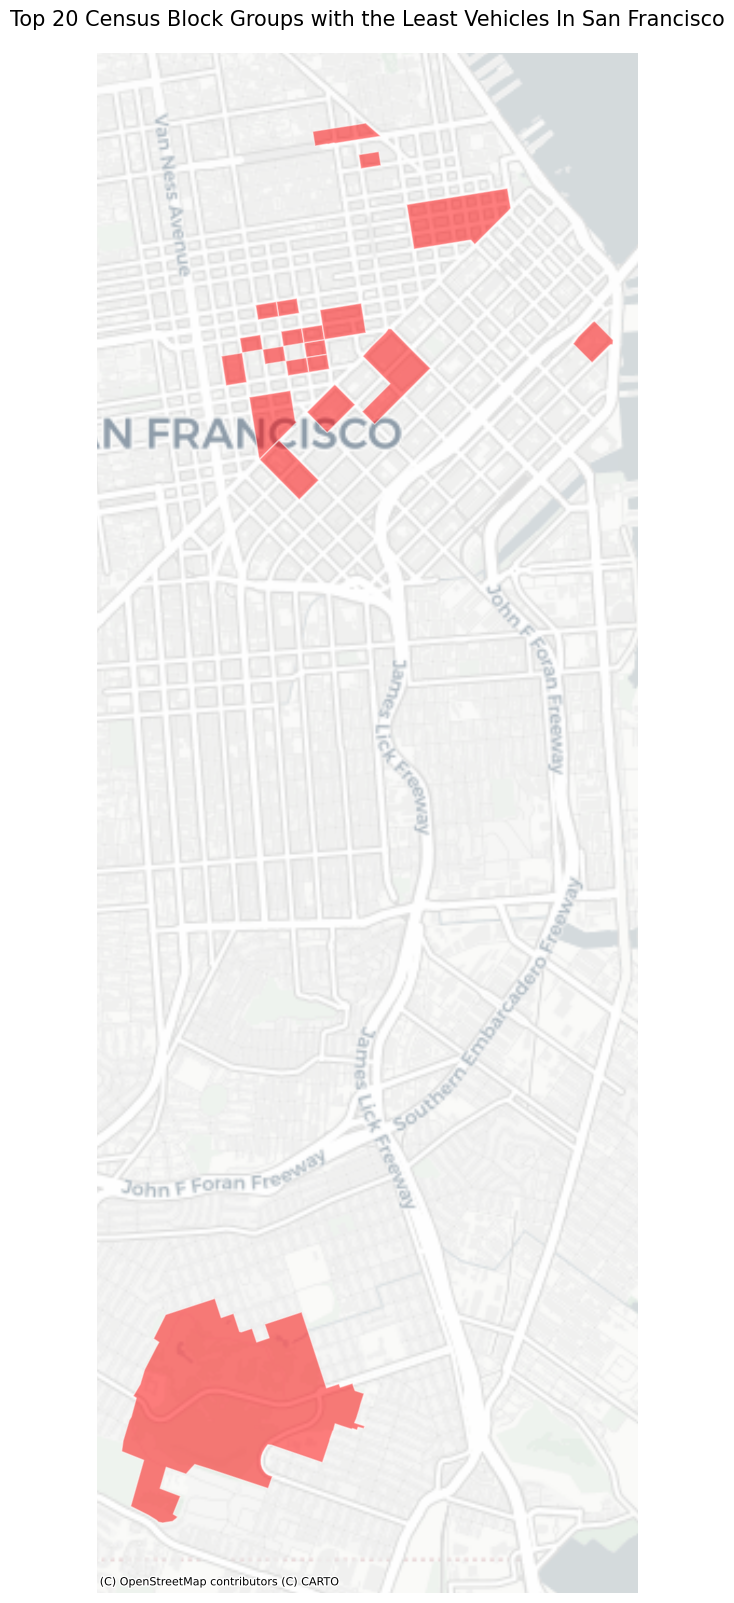

In [26]:
# map the top 20 geographies
fig,ax = plt.subplots(figsize=(20,20))
sf.sort_values(by='vehicles_per_1000', ascending=True)[:20].plot(ax=ax,
                                                                 color='red',
                                                                 edgecolor='white',
                                                                 alpha=0.5)


# title
ax.set_title('Top 20 Census Block Groups with the Least Vehicles In San Francisco',fontsize=15,pad=20)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

From this map, we can see that the lowest census block groups with total number of vehicles are located. Now, I am going to map the entire city. 

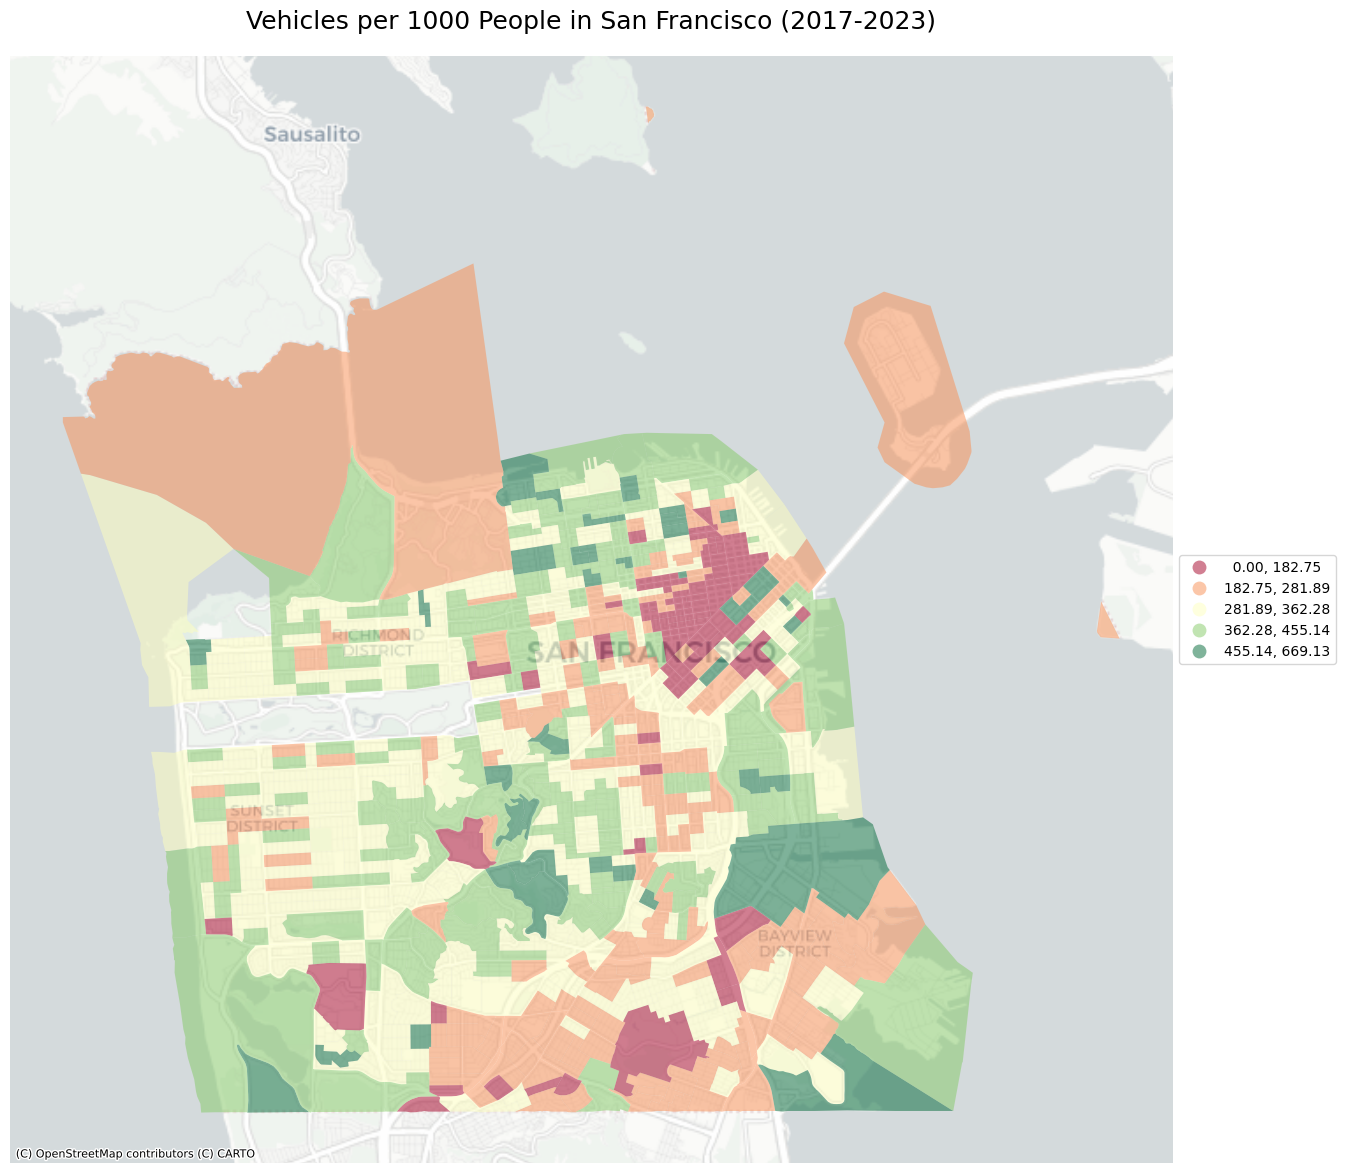

In [27]:
# create subplots to recieve cloropleth maps
fig,ax = plt.subplots(figsize=(15,15))

sf.plot(ax=ax,
        column='vehicles_per_1000', # this defines the field to "choropleth"
        legend=True,
        alpha=0.5,
        cmap='RdYlGn', # the "_r" reverses the color
        scheme='naturalbreaks', # use quantiles when data is naturally distributied (not left or right skewed) check with histogram, use naturalbreaks when skewed
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})

ax.axis('off')
ax.set_title('Vehicles per 1000 People in San Francisco (2017-2023)',fontsize=18,pad=20)
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

In [34]:
# interactive version in geopandas
sf.explore(column='vehicles_per_1000', # this defines the field to "choropleth"
        legend=True,
        cmap='RdYlGn',
        scheme='naturalbreaks',
        tiles='CartoDB positron',
        style_kwds={
            'weight':0.5,
            'color':'black',
            'opacity':0.5
        })

From this map, we can see that the lowest amount of vehicles are located on the Upper East side of the city, near the Tenderlion and "South of Market Street" districts. They are also scattered along the far southern areas of the city. We can also see that block groups with similar vehicle access rates are loosely clustered together. 

From our prior research, we know that the Tenderlion and "South of Market Street" districts are serviced by several Bay Area Rapid Transportation (BART) lines. Households living in these areas may not need vehicles if they feel adequately supported by the public transportation options in their area. 

Based on these findings, it would be useful to see if income is correlated with decreased car access in neighborhoods served by BART with no vehicle ownerhsip. 

## Global Spatial Autocorrelation

Now that we have seen that block groups with similar vehicle access rates are loosely clustered together, we are going to use global spatial autocorrelation to determine if there is any statitistical support to the apparent spatial clustering on the maps, or whether this pattern is due to chance. 

### Spatial Weights
To do this, I need to determine the spatial weights of the dataframe. This is used to determine the 'neighborhood' of a census block. 

In [29]:
# calculate spatial weight
wq =  lps.weights.KNN.from_dataframe(sf,k=8)

# Row-standardization
wq.transform = 'r'

Now, I am using the spatial weights to caluclate the spatial lag, which 

In [30]:
# create a new column for the spatial lag
sf['vehicles_per_1000_lag'] = lps.weights.lag_spatial(wq, sf['vehicles_per_1000'])

sf.head(1)

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles,total_vehicles,vehicles_per_1000,vehicles_per_1000_lag
0,60750101011,957.0,"MULTIPOLYGON (((-13627851.843 4553026.92, -136...",123826.0,541,185,276,80,0,0,0,356,371.99582,351.28472


In [31]:
# create a column that calculates the difference between arrests and lag
sf['vehicle_lag_diff'] = sf['vehicles_per_1000'] - sf['vehicles_per_1000_lag']

sf.head(1)

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles,total_vehicles,vehicles_per_1000,vehicles_per_1000_lag,vehicle_lag_diff
0,60750101011,957.0,"MULTIPOLYGON (((-13627851.843 4553026.92, -136...",123826.0,541,185,276,80,0,0,0,356,371.99582,351.28472,20.7111


In [32]:
# output to get the head and tail
sf.sort_values(by='vehicle_lag_diff')

,FIPS,TotalPop,geometry,Median Household Income,Occupied Housing Units,No Vehicles,One Vehicle,Two Vehicles,3 Vehicles,4 Vehicles,5 + Vehicles,total_vehicles,vehicles_per_1000,vehicles_per_1000_lag,vehicle_lag_diff
669,60750615082,891.0,"MULTIPOLYGON (((-13624537.305 4549078.168, -13...",150063.0,539,471,68,0,0,0,0,68,76.318743,427.014303,-350.695560
461,60750305003,1575.0,"MULTIPOLYGON (((-13632348.482 4544383.428, -13...",NaN,290,89,86,67,48,0,0,201,127.619048,380.229806,-252.610758
541,60750332011,3535.0,"MULTIPOLYGON (((-13635142.156 4541306.056, -13...",68250.0,595,201,232,144,8,10,0,394,111.456860,346.159902,-234.703042
161,60750157012,2178.0,"MULTIPOLYGON (((-13631652.401 4548055.476, -13...",140536.0,340,91,203,46,0,0,0,249,114.325069,348.818631,-234.493562
667,60750615071,1550.0,"MULTIPOLYGON (((-13625211.678 4550152.941, -13...",167785.0,771,438,313,10,10,0,0,333,214.838710,440.705760,-225.867051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,60750124053,660.0,"MULTIPOLYGON (((-13627808.762 4548668.995, -13...",111392.0,505,232,252,0,21,0,0,273,413.636364,172.522428,241.113936
654,60750615012,413.0,"MULTIPOLYGON (((-13626180.492 4549204.515, -13...",250001.0,255,65,190,0,0,0,0,190,460.048426,217.970127,242.078299
14,60750104023,413.0,"MULTIPOLYGON (((-13626176.262 4551328.558, -13...",NaN,295,94,177,24,0,0,0,201,486.682809,227.219729,259.463080
54,60750119012,274.0,"MULTIPOLYGON (((-13627076.057 4550001.649, -13...",211679.0,207,64,143,0,0,0,0,143,521.897810,233.373727,288.524083


### Spatial Lag Map

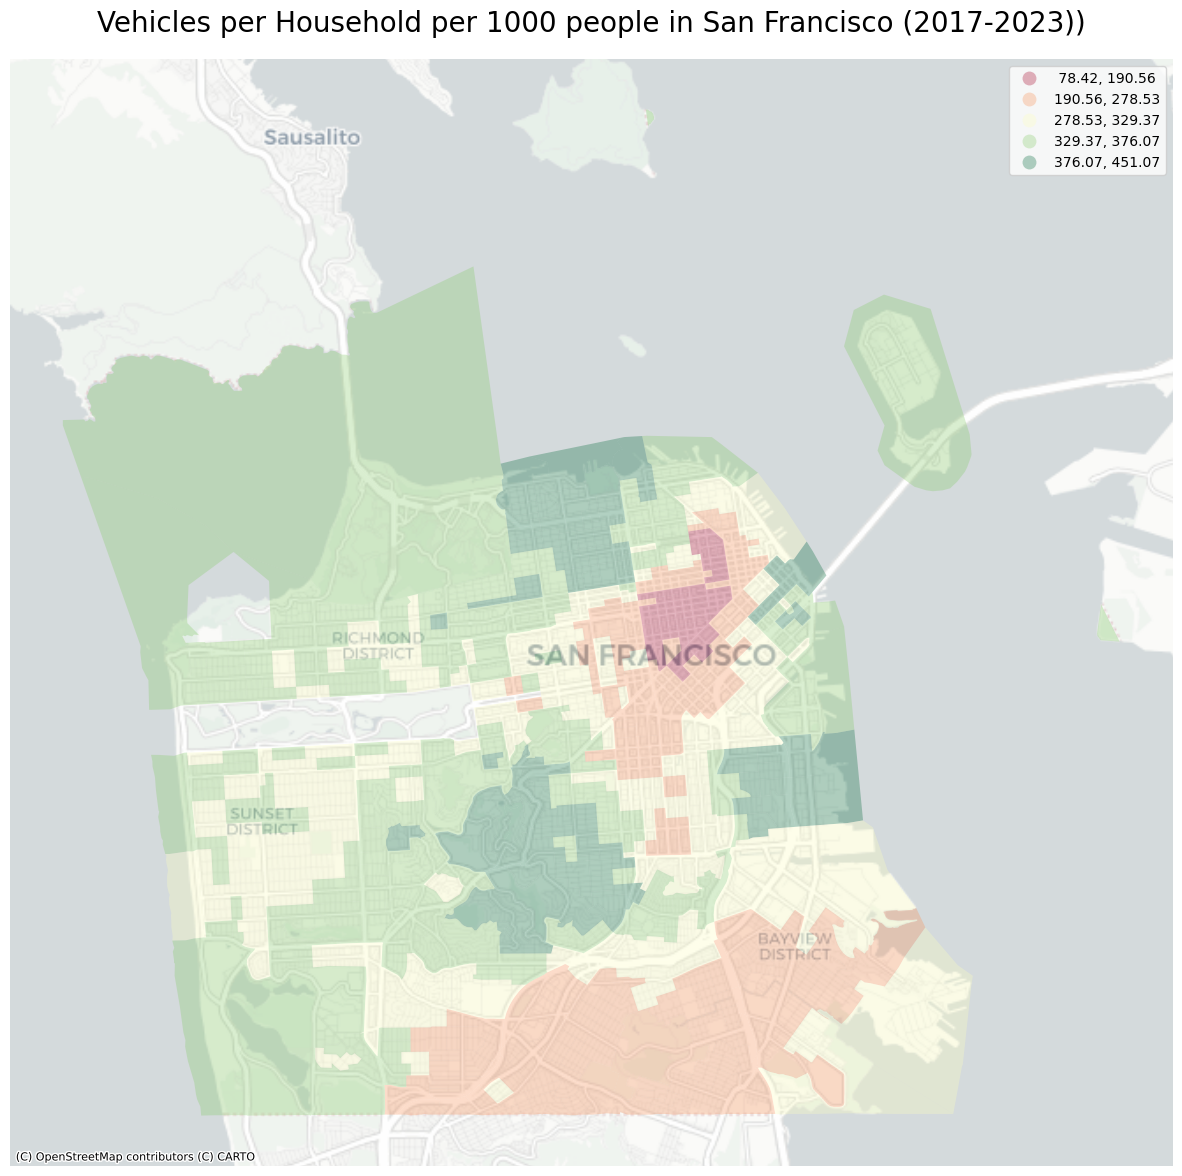

In [39]:
# use subplots that make it easier to create multiple layered maps
fig, ax = plt.subplots(figsize=(15, 15))

# spatial lag choropleth
sf.plot(ax=ax,
         figsize=(15,15),
         column='vehicles_per_1000_lag',
         legend=True,
         alpha=0.3,
         cmap='RdYlGn',
         scheme='naturalbreaks')

ax.axis('off')
ax.set_title('Vehicles per Household per 1000 people in San Francisco (2017-2023))',fontsize=20,pad=20)

ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

This map shows that the 

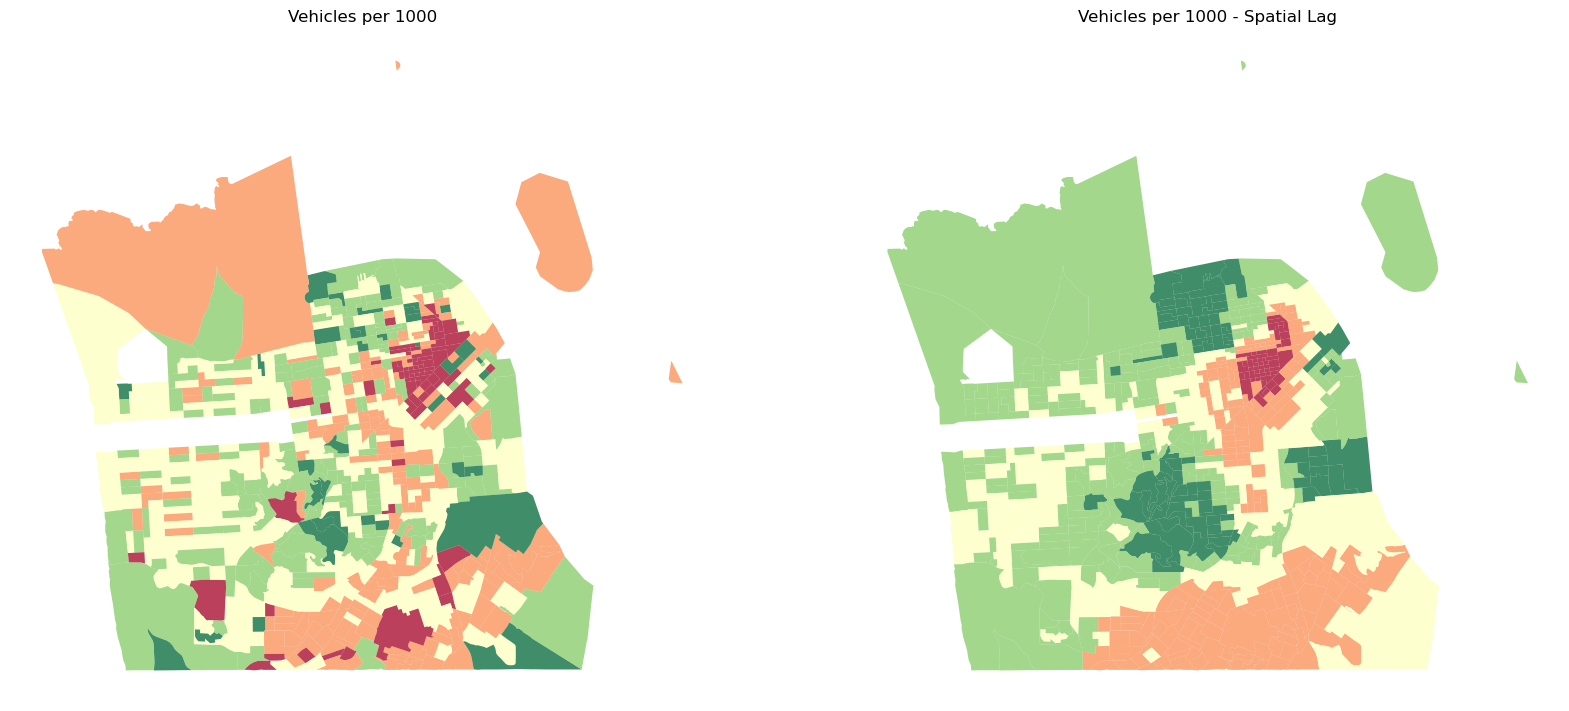

In [41]:
# create the 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# regular count map on the left
sf.plot(ax=ax[0], # this assigns the map to the left subplot
         column='vehicles_per_1000', 
         cmap='RdYlGn', 
         scheme='naturalbreaks',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75, 
           )


ax[0].axis("off")
ax[0].set_title("Vehicles per 1000")

# spatial lag map on the right
sf.plot(ax=ax[1], # this assigns the map to the right subplot
         column='vehicles_per_1000_lag', 
         cmap='RdYlGn', 
         scheme='naturalbreaks',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75
           )

ax[1].axis("off")
ax[1].set_title("Vehicles per 1000 - Spatial Lag")

plt.show()

We can see that the spatial lag gives us a map that looks much more cohesive where census block gorups are correlated with block groups that have similar amounts of vehicles per household. 

## Moran's Plot

In [42]:
y = sf.vehicles_per_1000
moran = Moran(y, wq)
moran.I

np.float64(0.44807293561049594)

This postive value tells us that there are high values are close to high values, and/or low values are close to low values (HH and LL). So basically, there are census blocks are close to other blocks with similar levels of vehicle ownership, such as high values of vehicle ownership next to other high levels, or low with low. 

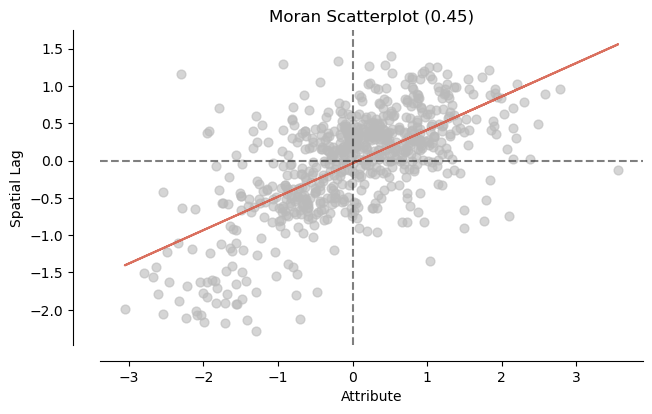

np.float64(0.001)

In [47]:
# moran's scatter plot
fig, ax = moran_scatterplot(moran, aspect_equal=True)
plt.show()

# the p value 
moran.p_sim

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.45', ylabel='Density'>)

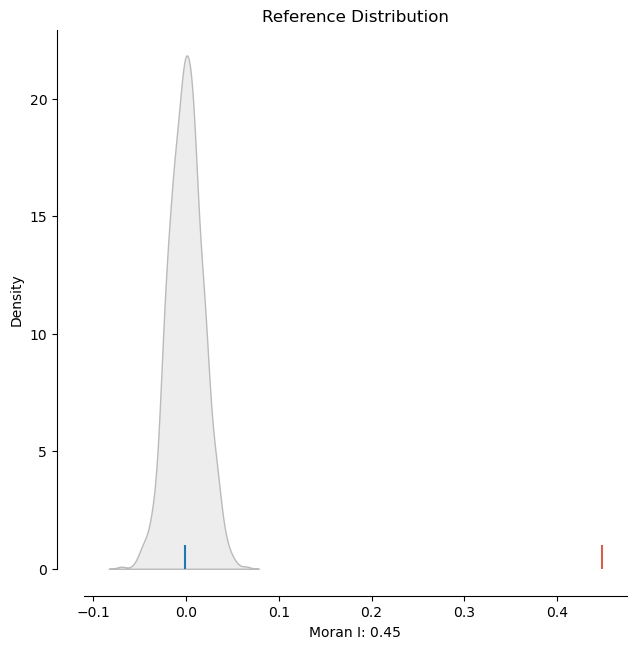

In [46]:
plot_moran_simulation(moran,aspect_equal=False)

### Moran's Plot Results: 

Because we are calcualting the statistical probabilty of this spatial pattern occuring randomly we have a p-value as with other statistical tests. Our p-value is 0.001, which tells us that there is only a 0.1% chance of this spatial pattern occuring randomly, if our null hypothesis is true. In this case, the null hypothesis is that this spatial pattern occured by chance. This value is small enough that we can reject the null hypothesis and say that the spatial pattern of vehicle access in San Francisco was not random.   

## Local Spatial Autocorrelation

**Local Spatial Autocorrelation**

Local spatial autocorrelation groups the clusters into 4 catergores: high values near to high values (HH), Low values with nearby low values (LL), Low values with high values in its neighborhood, and vice-versa.

In [48]:
# calculate local moran values
lisa = esda.moran.Moran_Local(y, wq)

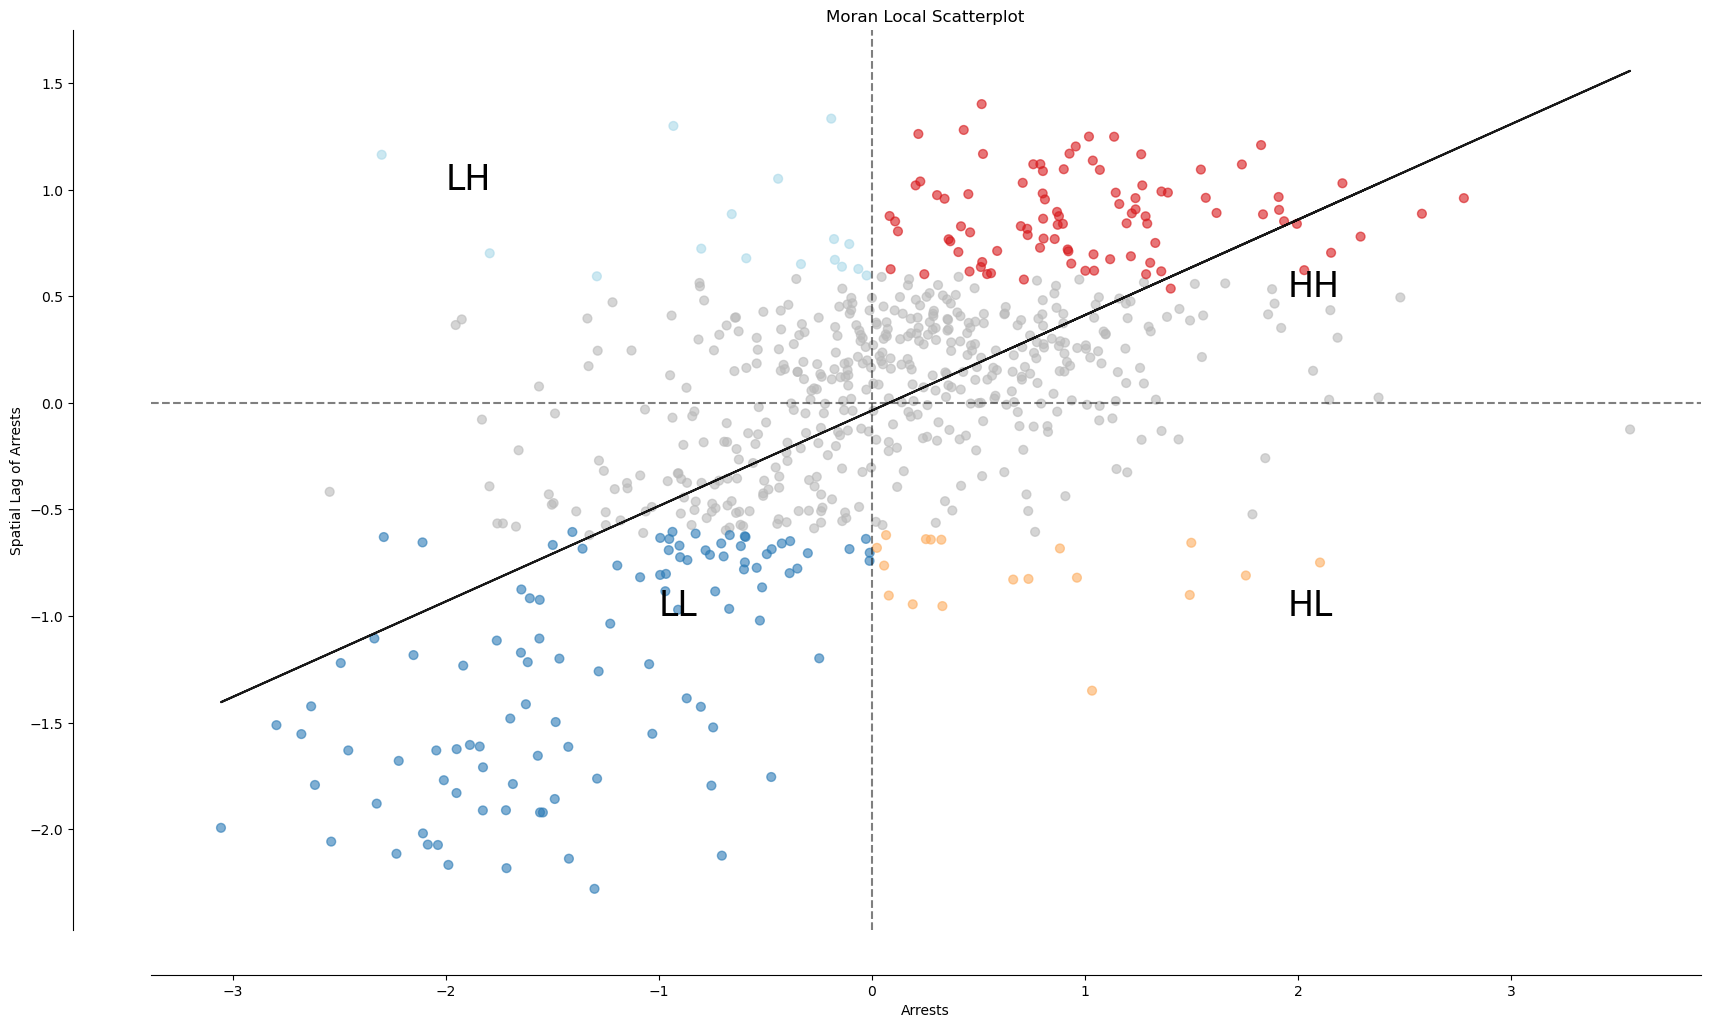

In [49]:
# Plot
fig,ax = plt.subplots(figsize=(20,15))

moran_scatterplot(lisa, ax=ax, p=0.05)
ax.set_xlabel("Arrests")
ax.set_ylabel('Spatial Lag of Arrests')

# add some labels
plt.text(1.95, 0.5, "HH", fontsize=25)
plt.text(1.95, -1, "HL", fontsize=25)
plt.text(-2, 1, "LH", fontsize=25)
plt.text(-1, -1, "LL", fontsize=25)
plt.show()

In the scatterplot, the colored dots represents census block groups that have a P-value less that 0.05 in each quadrant. In other words, these are the statisticaly significantly, spatially autocorrelated geographies.

### Spatial Autocorrelation Final Map

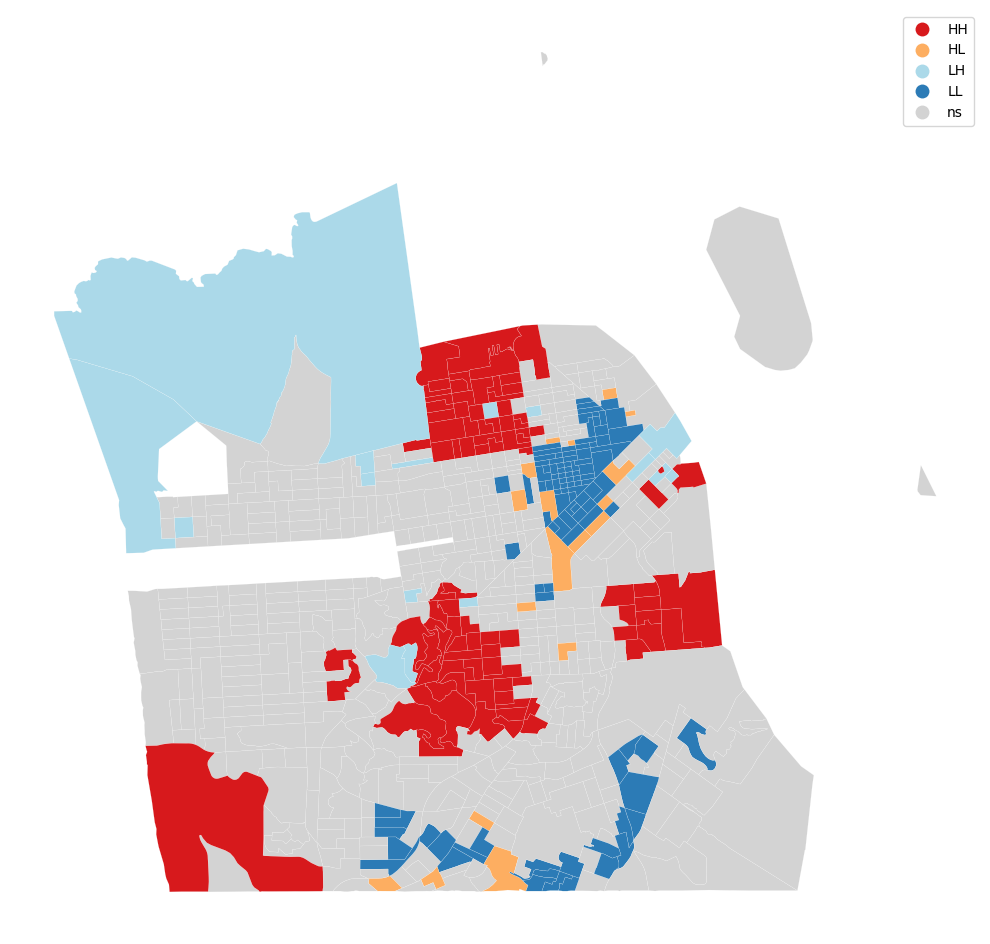

In [51]:
fig, ax = plt.subplots(figsize=(14,12))
lisa_cluster(lisa, sf, p=0.05, ax=ax)
plt.show()

### Interpretation: 

* Red (HH): high vehicle rate geographies near other high vehicle rate neighbors
* Orange (HL or diamonds): high vehicle rate geographies surrounded by low vehicle neighbors
* Light Blue (LH or donuts): low vehicle rate geographies surrounded by high vehicle neighbors
* Dark Blue (LL): low vehicle rate geographies near other low vehicle rate neighbors

This map is confirming that the areas we identified with low vehicle ownership (the Tenderlion and South of Market Street) appear to be out of place among other census tracks with high vehicle ownership. It is intersting that there are three large groups of HH (red) at the north, middle, and east of the map that did not intially appear in the original map of vehicle ownership. This could be due to high rates based on the amount of people in these areas due to geographical reasons.  

The vast majority of the city does not show statistically significant patterns between vehicle access, so we can conlude that there is likely geographical reasons that the regions that did have statistically significant pattrens either need or do not need access to vehicles. 

I am going to check the population differences quickly and compare. 

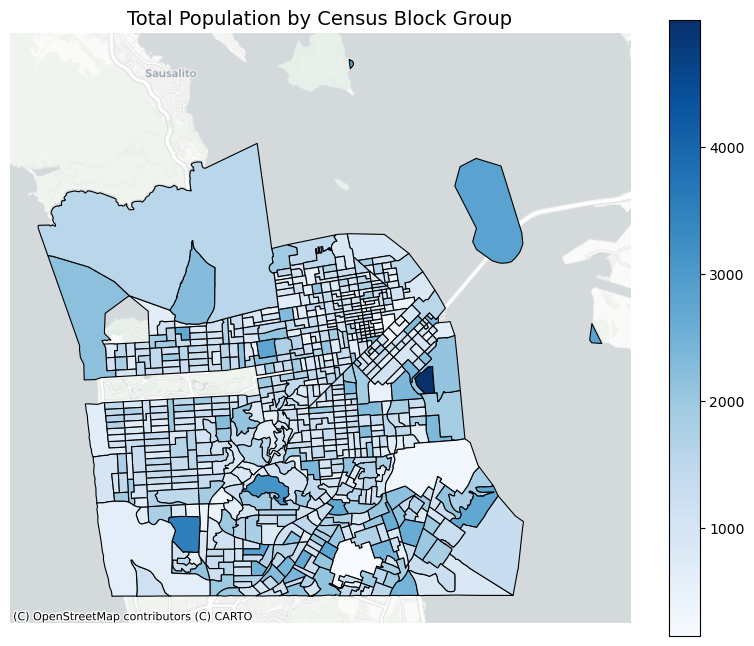

In [53]:
# create fig
fig, ax = plt.subplots(figsize=(10, 8))
sf.plot(column="TotalPop", cmap="Blues", linewidth=0.8, edgecolor="black", legend=True, ax=ax)

# add a basemap 
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=sf.crs)

# totle and axis
ax.set_title("Total Population by Census Block Group", fontsize=14)
ax.axis("off")  # Remove axis labels

# show 
plt.show()

**Group Contributions** 

The notebook represents Abigail's code.

Caleb, Ronald, and Jasmine contributed to the group discussion where we decided to look at vehicle ownership.

Jasmine contributed with the markdown documentation. 